# The conservation law: priority is a zero-sum game

You run a shared server with several classes of work and you want lower latency. So you give some
class higher priority. It works — *for that class*. But can clever prioritization lower the **total**
delay across everyone?

For a single server and blind (non-size-aware) work-conserving disciplines, the answer is **no**.
Kleinrock's conservation law says the load-weighted sum of waiting times

`Σ_i ρ_i · W_i = constant`

is **the same for every such discipline**, including plain FCFS. Priority only *moves* delay from
one class to another; it never removes it. Let's watch the numbers shuffle while the total stays
frozen.

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from most_queue.random.distributions import GammaDistribution
from most_queue.theory.priority.non_preemptive.mg1 import MG1NonPreemptiveCalc

plt.rcParams.update({"figure.figsize": (9, 5), "axes.grid": True, "font.size": 11})

LAMS = [0.30, 0.25, 0.20]          # three classes (A, B, C)
MEAN, CV = 1.0, 1.3
b = GammaDistribution.calc_theory_moments(GammaDistribution.get_params_by_mean_and_cv(MEAN, CV), 3)
RHO = [lam * MEAN for lam in LAMS]
print(f"class loads rho = {[round(x,2) for x in RHO]},  total rho = {sum(RHO):.2f}")

def waits_for_priority(order):
    # order: original class indices in priority order (highest first)
    c = MG1NonPreemptiveCalc()
    c.set_sources([LAMS[i] for i in order])
    c.set_servers([b for _ in order])
    w_by_pos = [x[0] if hasattr(x, "__len__") else x for x in c.run().w]
    W = [0.0, 0.0, 0.0]
    for pos, orig in enumerate(order):
        W[orig] = w_by_pos[pos]
    return W

def weighted_sum(W):
    return sum(RHO[i] * W[i] for i in range(3))


class loads rho = [0.3, 0.25, 0.2],  total rho = 0.75


## Reshuffle the priorities, watch the invariant

We try three priority orders (A>B>C, C>B>A, B>A>C) and, for each, the per-class mean wait `W_i` and
the conserved quantity `Σ ρ_i W_i`.

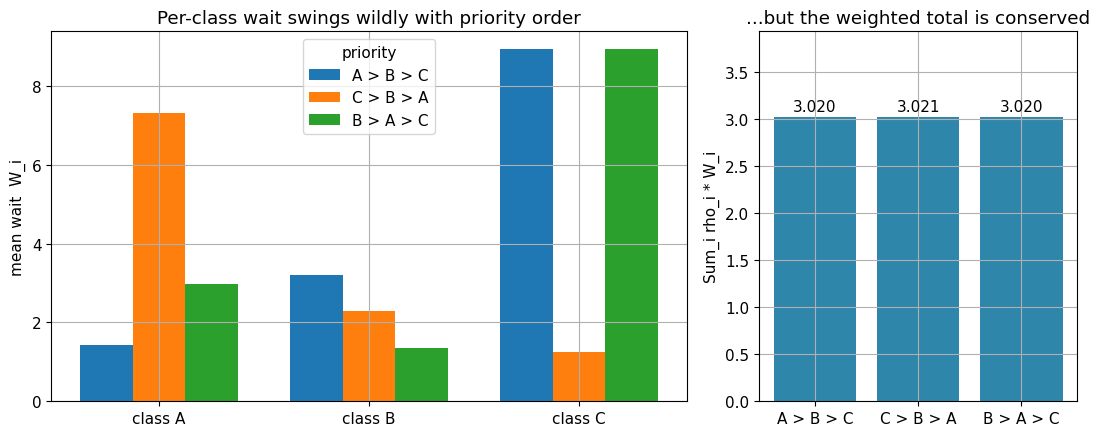

A > B > C:  W = [1.44, 3.2, 8.94]   Sum rho_i*W_i = 3.0202
C > B > A:  W = [7.32, 2.29, 1.26]   Sum rho_i*W_i = 3.0208
B > A > C:  W = [2.99, 1.34, 8.94]   Sum rho_i*W_i = 3.0203


In [2]:
orders = {"A > B > C": (0, 1, 2), "C > B > A": (2, 1, 0), "B > A > C": (1, 0, 2)}
labels = ["A", "B", "C"]
data = {name: waits_for_priority(o) for name, o in orders.items()}

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(11, 4.5), gridspec_kw={"width_ratios": [2, 1]})
x = np.arange(3); w = 0.25
for k, (name, W) in enumerate(data.items()):
    ax1.bar(x + (k - 1) * w, W, w, label=name)
ax1.set_xticks(x); ax1.set_xticklabels([f"class {l}" for l in labels])
ax1.set_ylabel("mean wait  W_i")
ax1.set_title("Per-class wait swings wildly with priority order")
ax1.legend(title="priority")

sums = [weighted_sum(W) for W in data.values()]
ax2.bar(list(data.keys()), sums, color="#2e86ab")
ax2.set_ylim(0, max(sums) * 1.3)
ax2.set_ylabel("Sum_i rho_i * W_i")
ax2.set_title("...but the weighted total is conserved")
for i, s in enumerate(sums):
    ax2.annotate(f"{s:.3f}", (i, s), textcoords="offset points", xytext=(0, 4), ha="center")
plt.tight_layout()
plt.show()

for name, W in data.items():
    print(f"{name}:  W = {[round(x,2) for x in W]}   Sum rho_i*W_i = {weighted_sum(W):.4f}")


**The insight.** The per-class waits move enormously — the class you promote can wait many times
less, the one you demote many times more — yet `Σ ρ_i W_i` is **identical to four digits** across all
orders. Prioritization is pure redistribution: it is a *zero-sum game* in load-weighted delay.

## So how do you actually reduce total delay?

Since blind class-priority can't lower the weighted total, you need **more information** or a
**different resource**:

- **Use job sizes.** Size-aware disciplines (SJF, **SRPT**) are not on this conservation surface —
  they exploit knowledge blind disciplines don't have, and genuinely lower the mean response time.
  See [disciplines_comparison.ipynb](disciplines_comparison.ipynb) and
  [srpt_basics.ipynb](srpt_basics.ipynb).
- **Reduce the residual work** that drives `W_0` — cut the service-time second moment (see
  [variability_matters.ipynb](variability_matters.ipynb)) or the load itself.
- **Add capacity / pool servers** (see [utilization_trap.ipynb](utilization_trap.ipynb)).

Priority is the right tool when some classes genuinely matter more (put the latency where it hurts
least) — just don't expect it to shrink the pie.

## Takeaways

- Kleinrock's conservation law: for blind work-conserving single-server disciplines,
  `Σ ρ_i W_i` is invariant. **Priority redistributes delay; it doesn't remove it.**
- To lower the *total*, use size information (SRPT), cut service variability, or add capacity.